### Library

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
import multiprocessing as mp
if mp.get_start_method(allow_none=True) is None:
    mp.set_start_method('spawn')

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*input_shape.*')
warnings.filterwarnings('ignore', message='.*structure of.*inputs.*')

import os, time, gc
from types import SimpleNamespace

import numpy as np
import pandas as pd
import time as time_module
from scipy.stats import t
from scipy.special import kv, gamma

import jax, jax.numpy as jnp

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

import optuna
import plotly.io as pio

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

2026-02-13 17:14:45.639712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770974085.669844  861795 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770974085.674575  861795 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770974085.686386  861795 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770974085.686408  861795 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770974085.686409  861795 computation_placer.cc:177] computation placer alr

### Environment setting

In [3]:
np_f32 = np.float32
jnp_f32 = jnp.float32
dtype_basis = np.float32

jax.config.update("jax_enable_x64", False)

pio.renderers.default = "notebook"
warnings.filterwarnings("ignore", category=UserWarning)

os.environ.update({"TF_CPP_MIN_LOG_LEVEL": "2"})
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.environ.setdefault("OMP_NUM_THREADS", "12")
os.environ.setdefault("MKL_NUM_THREADS", "12")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "12")

def init_hardware(dtype: str = "float32"):
    policy = mixed_precision.Policy(dtype)
    mixed_precision.set_global_policy(policy)
    
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU found and configured: {[gpu.name for gpu in gpus]}")
    else:
        print("⚠️ No GPU found")
    
    return tf.distribute.OneDeviceStrategy("/GPU:0" if gpus else "/CPU:0")

strategy = init_hardware()

✅ GPU found and configured: ['/physical_device:GPU:0']


I0000 00:00:1770974089.258040  861795 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17712 MB memory:  -> device: 0, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:70:00.0, compute capability: 8.9


### Auto save notebook

In [4]:
from IPython.display import display, Javascript

def save_notebook():
    display(Javascript('IPython.notebook.save_checkpoint()'))
    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
    print(f"💾 Notebook saved at {current_time}")

### Our function

In [5]:
from spherical_deepkriging.basis_functions.wendland.wenland import wendland
from spherical_deepkriging.basis_functions.mrts.mrts import mrts0

from spherical_deepkriging.models.deep_kriging import DeepKrigingTrainer
from spherical_deepkriging.configs import DeepKrigingModelConfig

from rpy2.robjects.conversion import localconverter
from spherical_deepkriging.basis_functions.mrts_sphere.sphere import mrts_sphere, numpy2ri_converter

R callback write-console: Registered S3 methods overwritten by 'RcppEigen':
  method               from         
  predict.fastLm       RcppArmadillo
  print.fastLm         RcppArmadillo
  summary.fastLm       RcppArmadillo
  print.summary.fastLm RcppArmadillo
  


### Simulation Helper

In [6]:
def simulate_data(num_sample, seed, signal_scale):
    """
    Experiment: Stationary Gaussian processes + Linear Mean Function.
    """
    rng = np.random.default_rng(seed)
    
    # Generate spherical coordinates uniformly
    phi = rng.uniform(0, 2 * np.pi, num_sample)
    theta = np.arccos(rng.uniform(-1, 1, num_sample))
    lat_rad = np.pi/2 - theta
    lon_rad = phi - np.pi
    
    lat_deg = np.rad2deg(lat_rad).astype(np.float32)
    lon_deg = np.rad2deg(lon_rad).astype(np.float32)
    
    # Convert to Cartesian coordinates
    x_cart = np.cos(lat_rad) * np.cos(lon_rad)
    y_cart = np.cos(lat_rad) * np.sin(lon_rad)
    z_cart = np.sin(lat_rad)

    # Linear Mean Function: 2*x + 4*y - z
    mean_term = signal_scale * (2.0 * x_cart + 4.0 * y_cart - z_cart).astype(np.float32)
    
    coords = np.column_stack([x_cart, y_cart, z_cart]).astype(np.float32)
    
    # Covariance matrix with exponential covariance function
    dist_matrix = np.arccos(np.clip(coords @ coords.T, -1.0, 1.0))
    cov_matrix = np.exp(-dist_matrix / 0.5).astype(np.float32)
    
    # Add jitter for numerical stability
    jitter = 1e-3
    cov_matrix += np.float32(jitter) * np.eye(num_sample, dtype=np.float32)
    
    # Cholesky decomposition with error handling
    try:
        L = np.linalg.cholesky(cov_matrix)
    except np.linalg.LinAlgError:
        cov_matrix += np.float32(1e-2) * np.eye(num_sample, dtype=np.float32)
        try:
            L = np.linalg.cholesky(cov_matrix)
        except np.linalg.LinAlgError:
            eigenvals, eigenvecs = np.linalg.eigh(cov_matrix)
            eigenvals = np.maximum(eigenvals, 1e-6)
            L = eigenvecs @ np.diag(np.sqrt(eigenvals))
    
    # Generate Gaussian process: y = mean + L @ z
    z_std = rng.standard_normal(num_sample).astype(np.float32)
    spatial_noise = (L @ z_std).astype(np.float32)
    y = mean_term + spatial_noise
    
    # Calculate Signal-to-Noise Ratio (SNR) statistics
    signal_var = np.var(mean_term, ddof=1)
    noise_var = np.var(spatial_noise, ddof=1)
    snr = signal_var / noise_var
    snr_db = 10 * np.log10(snr)
    
    total_var = np.var(y, ddof=1)
    
    # Calculate Standard Errors (SE) pre-calculation for cleaner code
    se_signal = np.std(mean_term, ddof=1) / np.sqrt(num_sample)
    se_noise = np.std(spatial_noise, ddof=1) / np.sqrt(num_sample)
    se_combined = np.std(y, ddof=1) / np.sqrt(num_sample)

    print(f"\n📊 Simulate Data Statistics (signal_scale={signal_scale:.2f})")
    print("=" * 80)

    print(f"\n{'Component':<15} {'Mean':>10} {'SE':>10} {'Variance':>10} {'Range':>30}")
    print("-" * 80)
    print(f"{'Signal':<15} {np.mean(mean_term):>10.4f} {se_signal:>10.4f} {signal_var:>10.4f} [{np.min(mean_term):>7.4f}, {np.max(mean_term):>7.4f}]")
    print(f"{'Noise':<15} {np.mean(spatial_noise):>10.4f} {se_noise:>10.4f} {noise_var:>10.4f} [{np.min(spatial_noise):>7.4f}, {np.max(spatial_noise):>7.4f}]")
    print(f"{'Combined':<15} {np.mean(y):>10.4f} {se_combined:>10.4f} {total_var:>10.4f} [{np.min(y):>7.4f}, {np.max(y):>7.4f}]")

    print(f"\n{'Metric':<20} {'Value':>15} {'Unit/Percent':>15}")
    print("-" * 80)
    print(f"{'SNR (Linear)':<20} {snr:>15.4f} {'-':>15}")
    print(f"{'SNR (dB)':<20} {snr_db:>15.2f} {'dB':>15}")
    print(f"{'Signal Partition':<20} {signal_var/total_var*100:>15.1f} {'%':>15}")
    print(f"{'Noise Partition':<20} {noise_var/total_var*100:>15.1f} {'%':>15}")
    print("=" * 80)
    
    z = y
    
    del phi, theta, lat_rad, lon_rad, x_cart, y_cart, z_cart, coords, dist_matrix, cov_matrix, L, z_std
    gc.collect()
    
    # Return both data and SNR info
    snr_info = {
        'signal_var': float(signal_var),
        'noise_var': float(noise_var),
        'total_var': float(total_var),
        'snr': float(snr),
        'snr_db': float(snr_db),
        'signal_scale': float(signal_scale)
    }
    
    return pd.DataFrame({
        "longitude": lon_deg,
        "latitude": lat_deg,
        "z": z,
    }), snr_info

### Helper Functions

In [7]:
def data_preprocessing(data_frame):
    data = data_frame.copy()

    numeric_cols = ["longitude", "latitude", "z"]
    data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors="coerce")
    data.dropna(subset=numeric_cols, inplace=True)

    lon, lat = data["longitude"].to_numpy(), data["latitude"].to_numpy()

    norm_lon = (lon - lon.min()) / (lon.max() - lon.min())
    norm_lat = (lat - lat.min()) / (lat.max() - lat.min())

    location_data = np.column_stack([lat, lon]).astype("float32")
    location_data_norm = np.column_stack([norm_lon, norm_lat]).astype("float32")
    y_combined = data['z'].to_numpy().astype("float32")[:, None]

    categorical_data = None

    return location_data, location_data_norm, categorical_data, y_combined


def precompute_max_mrts(distance_type, location_data, knot_num, order_max, knot=None):
    if knot is None:
        idx_knot = np.random.choice(location_data.shape[0], knot_num, replace=False)
        knot = location_data[idx_knot].astype(np_f32)
    else:
        idx_knot = None

    if distance_type == "sphere":
        with localconverter(numpy2ri_converter):
            res_r = mrts_sphere(knot, order_max, location_data.astype(np_f32))
        res_dict = dict(zip(res_r.names(), res_r))
        phi = np.asarray(res_dict["mrts"], dtype=dtype_basis)
    else:
        phi = np.asarray(
            mrts0(jnp.asarray(knot, dtype=jnp_f32), k=order_max, 
                  x=jnp.asarray(location_data, dtype=jnp_f32)), dtype=dtype_basis
        )

    return phi, idx_knot, knot


def prepare_data(categorical_data, basis, y_combined, seed, split_ratio=(0.8, 0.1, 0.1)):
    idx_all = np.arange(basis.shape[0])
    train_ratio, val_ratio, test_ratio = split_ratio
    
    train_val_x1, test_x1 = train_test_split(
        idx_all, train_size=train_ratio+val_ratio, random_state=seed)
    train_x1, val_x1 = train_test_split(
        train_val_x1, train_size=train_ratio/(train_ratio+val_ratio), random_state=seed)
    
    X_train_cont, X_val_cont, X_test_cont = (
        basis[train_x1], basis[val_x1], basis[test_x1])
    y_train, y_val, y_test = (
        y_combined[train_x1], y_combined[val_x1], y_combined[test_x1])
    
    def flatten(targets):
        return targets.reshape(-1).astype(np_f32, copy=False)
    y_train_flat, y_val_flat, y_test_flat = map(flatten, [y_train, y_val, y_test])

    def flatten(covariates):
        return covariates.reshape(-1, basis.shape[1]).astype(np_f32)
    X_train_cont_flat, X_val_cont_flat, X_test_cont_flat = map(flatten, [X_train_cont, X_val_cont, X_test_cont])
    
    # Handle categorical features
    if categorical_data is None:
        zero_vector = lambda n: np.zeros((n, 0), dtype=np_f32)
        X_train_cat, X_val_cat, X_test_cat = map(zero_vector, [len(X_train_cont_flat), len(X_val_cont_flat), len(X_test_cont_flat)])
    else:
        cat_train = categorical_data.reshape(-1, 1)[train_x1]
        cat_val = categorical_data.reshape(-1, 1)[val_x1]
        cat_test = categorical_data.reshape(-1, 1)[test_x1]
        
        OHE = OneHotEncoder(sparse_output=False, dtype=np_f32)
        X_train_cat = OHE.fit_transform(cat_train).astype(np_f32)
        X_val_cat = OHE.transform(cat_val).astype(np_f32)
        X_test_cat = OHE.transform(cat_test).astype(np_f32)
    
    return (X_train_cont_flat, X_train_cat, y_train_flat,
            X_val_cont_flat, X_val_cat, y_val_flat,
            X_test_cont_flat, X_test_cat, y_test_flat, test_x1)


def train_eval(name_model, epochs, batch_size, loss, dropout_rate,
               X_train, X_train_cat, y_train,
               X_val, X_val_cat, y_val,
               X_test, X_test_cat, y_test, test_x1):
    
    optimizer = Adam(learning_rate=5e-3)
    config = DeepKrigingModelConfig(
        input_dim=X_train.shape[1],
        output_type='continuous',
        hidden_layers=[1024, 512, 256, 128, 64],
        activation='relu',
        dropout_rate=dropout_rate,
        optimizer=optimizer,
        loss=loss,
        metrics=['mae'],
        epochs=epochs,
        batch_size=batch_size,
        patience=40,
        verbose=0
    )

    t0 = time.time()
    with strategy.scope():
        model = DeepKrigingTrainer(config)
        model.model.compile(optimizer=config.optimizer, loss=config.loss, metrics=config.metrics)

    checkpoint_path = f"best_{name_model}_{time.time_ns()}.weights.h5"
    
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path, monitor="val_loss", mode="min",
            save_best_only=True, save_weights_only=True, verbose=0)
    ]

    train_dataset = tf.data.Dataset.from_tensor_slices((
        (X_train, X_train_cat), y_train
    )).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.from_tensor_slices((
        (X_val, X_val_cat), y_val
    )).batch(config.batch_size).prefetch(tf.data.AUTOTUNE)

    history = model.model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=0
    )

    # Load best weights based on validation loss
    if os.path.exists(checkpoint_path):
        model.model.load_weights(checkpoint_path)
        os.remove(checkpoint_path)
    
    # Find the epoch with best validation loss
    best_epoch = np.argmin(history.history["val_loss"]) + 1
    val_loss = float(np.min(history.history["val_loss"]))
    
    y_pred = model.model.predict([X_test, X_test_cat], verbose=0).reshape(-1).astype(np_f32)
    training_time = time.time() - t0

    metrics = {
        "Model": name_model,
        "Best_Epoch": int(best_epoch),
        "Val_loss": float(val_loss),
        "MSPE": float(mean_squared_error(y_test, y_pred)),
        "RMSE": float(np.sqrt(float(mean_squared_error(y_test, y_pred)))),
        "MAE": float(mean_absolute_error(y_test, y_pred)),
        "R2": float(r2_score(y_test, y_pred)),
        "Time": float(training_time),
    }
    
    del train_dataset, val_dataset
    gc.collect()
    
    return metrics, model, history, y_pred, y_test


def cleanup_tf_session():
    tf.keras.backend.clear_session()
    gc.collect()
    try:
        tf.keras.backend.clear_session()
    except:
        pass

In [ ]:
def plot_robinson(ax, longitude, latitude, value, vmin, vmax, title):
    """Plot data on Robinson projection"""
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)

    sc = ax.scatter(longitude, latitude, c=value, 
                    cmap=mcolors.LinearSegmentedColormap.from_list("teal-yellow-red", ["#00AAAA", "#FFFFBB", "#FF3333"], N=256), 
                    s=10, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=10, pad=3)
    return sc


def create_subplot_robinson(fig, position, locations, values, vmin, vmax, title, plot_type='prediction', cbar_label=None):
    """Create subplot with Robinson projection"""
    ax = fig.add_subplot(*position, projection=ccrs.Robinson())
    
    # Choose colormap based on plot type
    if plot_type == 'residual':
        cmap = mcolors.LinearSegmentedColormap.from_list("blue-white-red", ["#2166AC", "#F7F7F7", "#B2182B"], N=256)
    else:
        cmap = mcolors.LinearSegmentedColormap.from_list("teal-yellow-red", ["#00AAAA", "#FFFFBB", "#FF3333"], N=256)
    
    # Set global view
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)
    
    # Plot scatter
    sc = ax.scatter(locations['longitude'], locations['latitude'], c=values, 
                    cmap=cmap, s=10, transform=ccrs.PlateCarree(), 
                    vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=10, pad=3)
    
    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04, shrink=0.8)
    
    if cbar_label is None:
        cbar_label = "Residual" if plot_type == 'residual' else "Prediction Value"
    
    # Increased fontsize to match old version
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=7)
    
    return ax, sc


def visualize_comparison(dataframe, models_dict, basis_dict, y_combined, seed, model_list=None, experiment_info=None):
    """Visualize model predictions and residuals using Robinson projection"""
    if model_list is None:
        model_list = ['DeepKriging_sphere', 'DeepKriging_sphere_Huber', 'UniversalKriging']
    
    idx_all = np.arange(len(y_combined))
    train_val_idx, test_idx = train_test_split(idx_all, train_size=0.9, random_state=seed)
    y_test = y_combined[test_idx].reshape(-1)
    test_locations = dataframe.iloc[test_idx]
    
    predictions = {}
    for model_name in model_list:
        if model_name not in models_dict or models_dict[model_name] is None:
            continue
        
        model = models_dict[model_name]
        X_test = basis_dict[model_name][test_idx]
        
        if "DeepKriging" in model_name:
            X_test_cat = np.zeros((len(X_test), 0), dtype=np.float32)
            y_pred = model.model.predict([X_test, X_test_cat], verbose=0).reshape(-1)
        elif model_name == "UniversalKriging":
            coords_test = dataframe[['longitude', 'latitude']].iloc[test_idx].values.astype(np.float32)
            y_pred = model.predict(coords_test, X_test, return_centered=False)
        else:
            y_pred = model.predict(X_test).reshape(-1)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        order = models_dict.get(f"{model_name}_order", "")
        
        predictions[model_name] = {
            'values': y_pred,
            'rmse': rmse,
            'order': order
        }
    
    # Calculate global min/max for consistent color scale
    all_values = [dataframe['z'].values] + [p['values'] for p in predictions.values()]
    all_values_concat = np.concatenate(all_values)
    vmin = np.percentile(all_values_concat, 2)
    vmax = np.percentile(all_values_concat, 98)
    
    # Figure 1: Predictions comparison
    fig1 = plt.figure(figsize=(16, 14))
    
    noise_info = ""
    if experiment_info:
        noise_info = f"Noise={experiment_info.get('noise', 'None')}"
        if experiment_info.get('noise_var'):
            noise_info += f", Var={experiment_info['noise_var']}"
    
    # Plot real data
    create_subplot_robinson(
        fig1, (2, 2, 1), dataframe, dataframe['z'], vmin, vmax,
        f'Real Data (n={len(dataframe)})',
        plot_type='prediction'
    )
    
    # Plot predictions
    subplot_positions = [(2, 2, 2), (2, 2, 3), (2, 2, 4)]
    for i, model_name in enumerate(model_list):
        if model_name in predictions:
            pred = predictions[model_name]
            display_name = model_name.replace('DeepKriging_sphere', 'DK_S').replace('_Huber', '_H').replace('UniversalKriging', 'UK')
            
            create_subplot_robinson(
                fig1, subplot_positions[i], test_locations, pred['values'], vmin, vmax,
                f"{display_name} (order={pred['order']}) | Test n={len(test_idx)} | RMSE={pred['rmse']:.4f}",
                plot_type='prediction'
            )
    
    # Modified title fontsize and layout to match old version
    plt.suptitle(
        "Prediction Comparison: Real Data vs. Models Predict\n"
        f"Stationary Gaussian processes + Eggholder (without noise and outliers)",
        fontsize=20, fontweight='bold', y=0.84
    )
    # Reverted to tight_layout with rect, as in the old version
    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()
    plt.close(fig1)
    

    # Figure 2: Residuals comparison
    fig2 = plt.figure(figsize=(18, 6))
    
    residuals_map = {k: (y_test - predictions[k]['values']) 
                     for k in model_list if k in predictions}
    vmax_abs = max(np.max(np.abs(r)) for r in residuals_map.values())
    
    for i, model_name in enumerate(model_list):
        if model_name in predictions:
            residuals = residuals_map[model_name]
            display_name = model_name.replace('DeepKriging_sphere', 'DK_S').replace('_Huber', '_H').replace('UniversalKriging', 'UK')
            
            create_subplot_robinson(
                fig2, (1, 3, i+1), test_locations, residuals, -vmax_abs, vmax_abs,
                f"{display_name} Residuals (order={predictions[model_name]['order']})",
                plot_type='residual'
            )
    
    # Modified title fontsize and layout to match old version
    plt.suptitle(
        f"Residuals Comparison | Stationary Gaussian processes + Eggholder (without noise and outliers)",
        fontsize=20, fontweight='bold', y=0.84
    )
    # Reverted to tight_layout with rect
    plt.tight_layout(rect=[0, 0.02, 1, 0.94])
    plt.show()
    plt.close(fig2)
    
    return predictions, test_idx

### Experiment Setup

In [8]:
# Fixed parameters
seed = 1
epochs = 500
batch_size = 256
num_sample = 2500
huber_delta = 1.345
dropout_rate = 0.01

# Basis parameters
knot_num = 1400
order_max = 500

# Experimental factors
basis_K = [50, 200, 400]
signal_scales = [1.0, 1.732051]

print(f"\n{'='*80}")
print(f"🔧 Experiment Configuration")
print(f"{'='*80}")
print(f"Fixed Parameters:")
print(f"  - Seed: {seed}")
print(f"  - Epochs: {epochs}")
print(f"  - Batch size: {batch_size}")
print(f"  - Num samples: {num_sample}")
print(f"  - Huber delta: {huber_delta}")
print(f"  - Dropout rate: {dropout_rate}")
print(f"\nExperimental Factors:")
print(f"  - Models: DeepKriging_mrts, DeepKriging_sphere_Huber")
print(f"  - Basis K: {basis_K}")
print(f"  - Signal scales: {signal_scales}")
print(f"{'='*80}\n")


🔧 Experiment Configuration
Fixed Parameters:
  - Seed: 1
  - Epochs: 500
  - Batch size: 256
  - Num samples: 2500
  - Huber delta: 1.345
  - Dropout rate: 0.01

Experimental Factors:
  - Models: DeepKriging_mrts, DeepKriging_sphere_Huber
  - Basis K: [50, 200, 400]
  - Signal scales: [1.0, 1.732051]



### Outcome


In [9]:
# Store all results
all_results = []
snr_records = []
training_histories = {}
predictions_data = {}

for signal_scale in signal_scales:
    print(f"\n{'='*80}")
    print(f"🎲 Signal Scale: {signal_scale}x")
    print(f"{'='*80}")
    
    # Generate data with specific noise scale
    dataframe, snr_info = simulate_data(num_sample=num_sample, seed=seed, signal_scale=signal_scale)
    snr_records.append(snr_info)
    
    # Preprocess data
    location_data, location_data_norm, categorical_data, y_combined = data_preprocessing(dataframe)

    # Precompute basis functions
    max_Phi_sphere, idx_knot, knot = precompute_max_mrts("sphere", location_data, knot_num, order_max, knot=None)
    max_Phi_sphere = max_Phi_sphere.astype(dtype_basis, copy=False)

    max_Phi_mrts, idx_knot_mrts, knot_mrts = precompute_max_mrts("mrts", location_data, knot_num, order_max, knot=location_data[idx_knot])
    max_Phi_mrts = max_Phi_mrts.astype(dtype_basis, copy=False)

    for num_basis in basis_K:
        print(f"\n{'-'*80}")
        print(f"📐 Basis K = {num_basis}")
        print(f"{'-'*80}")
        
        exp_key = f"signal_{signal_scale}_K_{num_basis}"
        
        # ============================================================
        # Model 1: DeepKriging_mrts with Huber Loss
        # ============================================================
        print(f"\nTraining DeepKriging_mrts with K={num_basis} | signal_scale={signal_scale}")
        
        Phi_mrts = max_Phi_mrts[:, :num_basis].astype(np_f32)
        parts = prepare_data(categorical_data, Phi_mrts, y_combined, seed)
        
        with strategy.scope():
            metrics, model, history, y_pred, y_test = train_eval(
                "DeepKriging_mrts", epochs, batch_size, Huber(delta=huber_delta), dropout_rate, *parts
            )
        
        # Store results
        result_record = {
            "Signal_Scale": signal_scale,
            "SNR": snr_info['snr'],
            "SNR_dB": snr_info['snr_db'],
            "Model": "DeepKriging_mrts_Huber",
            "K": num_basis,
            "Best_Epoch": metrics["Best_Epoch"],
            "Val_Loss": metrics["Val_loss"],
            "MSPE": metrics["MSPE"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "Time": metrics["Time"]
        }
        all_results.append(result_record)
        
        # Store history for plotting
        training_histories[f"{exp_key}_mrts"] = {
            'history': history.history,
            'model': 'DeepKriging_mrts_Huber',
            'K': num_basis,
            'noise_scale': signal_scale
        }
        
        # Store predictions for plotting (only for the first noise scale and K=200)
        if signal_scale == signal_scales[0] and num_basis == 200:
            predictions_data['mrts'] = {
                'y_true': y_test,
                'y_pred': y_pred,
                'test_idx': parts[-1],
                'dataframe': dataframe,
                'model_name': 'DeepKriging_mrts_Huber'
            }
        
        print(f"  ✅ Best Epoch: {metrics['Best_Epoch']}, Val Loss: {metrics['Val_loss']:.4f}, Test MSPE: {metrics['MSPE']:.4f}")
        
        del Phi_mrts, parts, model
        cleanup_tf_session()
        gc.collect()
        
        # ============================================================
        # Model 2: DeepKriging_sphere_Huber
        # ============================================================
        print(f"\nTraining DeepKriging_sphere_Huber with K={num_basis} | signal_scale={signal_scale}")
        
        Phi_sphere = max_Phi_sphere[:, :num_basis].astype(np_f32)
        parts = prepare_data(categorical_data, Phi_sphere, y_combined, seed)
        
        with strategy.scope():
            metrics, model, history, y_pred, y_test = train_eval(
                "DeepKriging_sphere_Huber", epochs, batch_size, Huber(delta=huber_delta), dropout_rate, *parts
            )
        
        # Store results
        result_record = {
            "Signal_Scale": signal_scale,
            "SNR": snr_info['snr'],
            "SNR_dB": snr_info['snr_db'],
            "Model": "DeepKriging_sphere_Huber",
            "K": num_basis,
            "Best_Epoch": metrics["Best_Epoch"],
            "Val_Loss": metrics["Val_loss"],
            "MSPE": metrics["MSPE"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "Time": metrics["Time"]
        }
        all_results.append(result_record)
        
        # Store history for plotting
        training_histories[f"{exp_key}_sphere"] = {
            'history': history.history,
            'model': 'DeepKriging_sphere_Huber',
            'K': num_basis,
            'signal_scale': signal_scale
        }
        
        # Store predictions for plotting (only for the first noise scale and K=200)
        if signal_scale == signal_scales[0] and num_basis == 200:
            predictions_data['sphere'] = {
                'y_true': y_test,
                'y_pred': y_pred,
                'test_idx': parts[-1],
                'dataframe': dataframe,
                'model_name': 'DeepKriging_sphere_Huber'
            }
        
        print(f"  ✅ Best Epoch: {metrics['Best_Epoch']}, Val Loss: {metrics['Val_loss']:.4f}, Test MSPE: {metrics['MSPE']:.4f}")
        
        del Phi_sphere, parts, model
        cleanup_tf_session()
        gc.collect()
    
    # Cleanup after each signal scale
    del max_Phi_sphere, max_Phi_mrts, dataframe, location_data, location_data_norm, y_combined
    cleanup_tf_session()
    gc.collect()
    
    save_notebook()
    print(f"\n✅ Completed signal scale {signal_scale}x")

print(f"\n{'='*80}")
print(f"🎉 All experiments completed!")
print(f"{'='*80}")


🎲 Signal Scale: 1.0x

📊 Simulate Data Statistics (signal_scale=1.00)

Component             Mean         SE   Variance                          Range
--------------------------------------------------------------------------------
Signal             -0.0392     0.0525     6.8979 [-4.5810,  4.5814]
Noise              -0.2303     0.0214     1.1486 [-3.4100,  3.1657]
Combined           -0.2695     0.0511     6.5192 [-5.6175,  5.3562]

Metric                         Value    Unit/Percent
--------------------------------------------------------------------------------
SNR (Linear)                  6.0058               -
SNR (dB)                        7.79              dB
Signal Partition               105.8               %
Noise Partition                 17.6               %


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.



--------------------------------------------------------------------------------
📐 Basis K = 50
--------------------------------------------------------------------------------

Training DeepKriging_mrts with K=50 | signal_scale=1.0
  ✅ Best Epoch: 487, Val Loss: 0.0737, Test MSPE: 0.1275

Training DeepKriging_sphere_Huber with K=50 | signal_scale=1.0
  ✅ Best Epoch: 411, Val Loss: 0.0535, Test MSPE: 0.0834

--------------------------------------------------------------------------------
📐 Basis K = 200
--------------------------------------------------------------------------------

Training DeepKriging_mrts with K=200 | signal_scale=1.0
  ✅ Best Epoch: 304, Val Loss: 0.0651, Test MSPE: 0.1397

Training DeepKriging_sphere_Huber with K=200 | signal_scale=1.0
  ✅ Best Epoch: 307, Val Loss: 0.0570, Test MSPE: 0.0918

--------------------------------------------------------------------------------
📐 Basis K = 400
---------------------------------------------------------------------------

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-13 17:50:29

✅ Completed signal scale 1.0x

🎲 Signal Scale: 1.732051x

📊 Simulate Data Statistics (signal_scale=1.73)

Component             Mean         SE   Variance                          Range
--------------------------------------------------------------------------------
Signal             -0.0680     0.0910    20.6938 [-7.9346,  7.9353]
Noise              -0.2303     0.0214     1.1486 [-3.4100,  3.1657]
Combined           -0.2982     0.0876    19.1970 [-8.7325,  8.6027]

Metric                         Value    Unit/Percent
--------------------------------------------------------------------------------
SNR (Linear)                 18.0173               -
SNR (dB)                       12.56              dB
Signal Partition               107.8               %
Noise Partition                  6.0               %

--------------------------------------------------------------------------------
📐 Basis K = 50
--------------------------------------------

<IPython.core.display.Javascript object>

💾 Notebook saved at 2026-02-13 18:31:13

✅ Completed signal scale 1.732051x

🎉 All experiments completed!


### Results Summary

#### Signal to Noise Ratio

In [10]:
# SNR Summary
snr_df = pd.DataFrame(snr_records)

print("\n" + "="*80)
print("📈 Signal-to-Noise Ratio (SNR) Summary")
print("="*80)
print(snr_df.to_markdown(index=False, tablefmt="github"))


📈 Signal-to-Noise Ratio (SNR) Summary
|   signal_var |   noise_var |   total_var |      snr |   snr_db |   signal_scale |
|--------------|-------------|-------------|----------|----------|----------------|
|      6.89793 |     1.14855 |     6.51918 |  6.00577 |  7.78569 |        1       |
|     20.6938  |     1.14855 |    19.197   | 18.0173  | 12.5569  |        1.73205 |


#### Model training results

In [11]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("📊 Results Table")
print("="*80)
print(results_df.to_markdown(index=False, tablefmt="github"))


📊 Results Table
|   Signal_Scale |      SNR |   SNR_dB | Model                    |   K |   Best_Epoch |   Val_Loss |      MSPE |     RMSE |      MAE |       R2 |    Time |
|----------------|----------|----------|--------------------------|-----|--------------|------------|-----------|----------|----------|----------|---------|
|        1       |  6.00577 |  7.78569 | DeepKriging_mrts_Huber   |  50 |          487 |  0.0737282 | 0.127502  | 0.357075 | 0.284655 | 0.980299 | 384.048 |
|        1       |  6.00577 |  7.78569 | DeepKriging_sphere_Huber |  50 |          411 |  0.0534953 | 0.0833742 | 0.288746 | 0.234481 | 0.987117 | 389.247 |
|        1       |  6.00577 |  7.78569 | DeepKriging_mrts_Huber   | 200 |          304 |  0.0650741 | 0.139708  | 0.373775 | 0.298824 | 0.978413 | 327.555 |
|        1       |  6.00577 |  7.78569 | DeepKriging_sphere_Huber | 200 |          307 |  0.0570114 | 0.0917875 | 0.302964 | 0.243048 | 0.985817 | 343.831 |
|        1       |  6.00577 |  7.78569 | 

#### Visualization 1: Training / Validataion Loss Curves

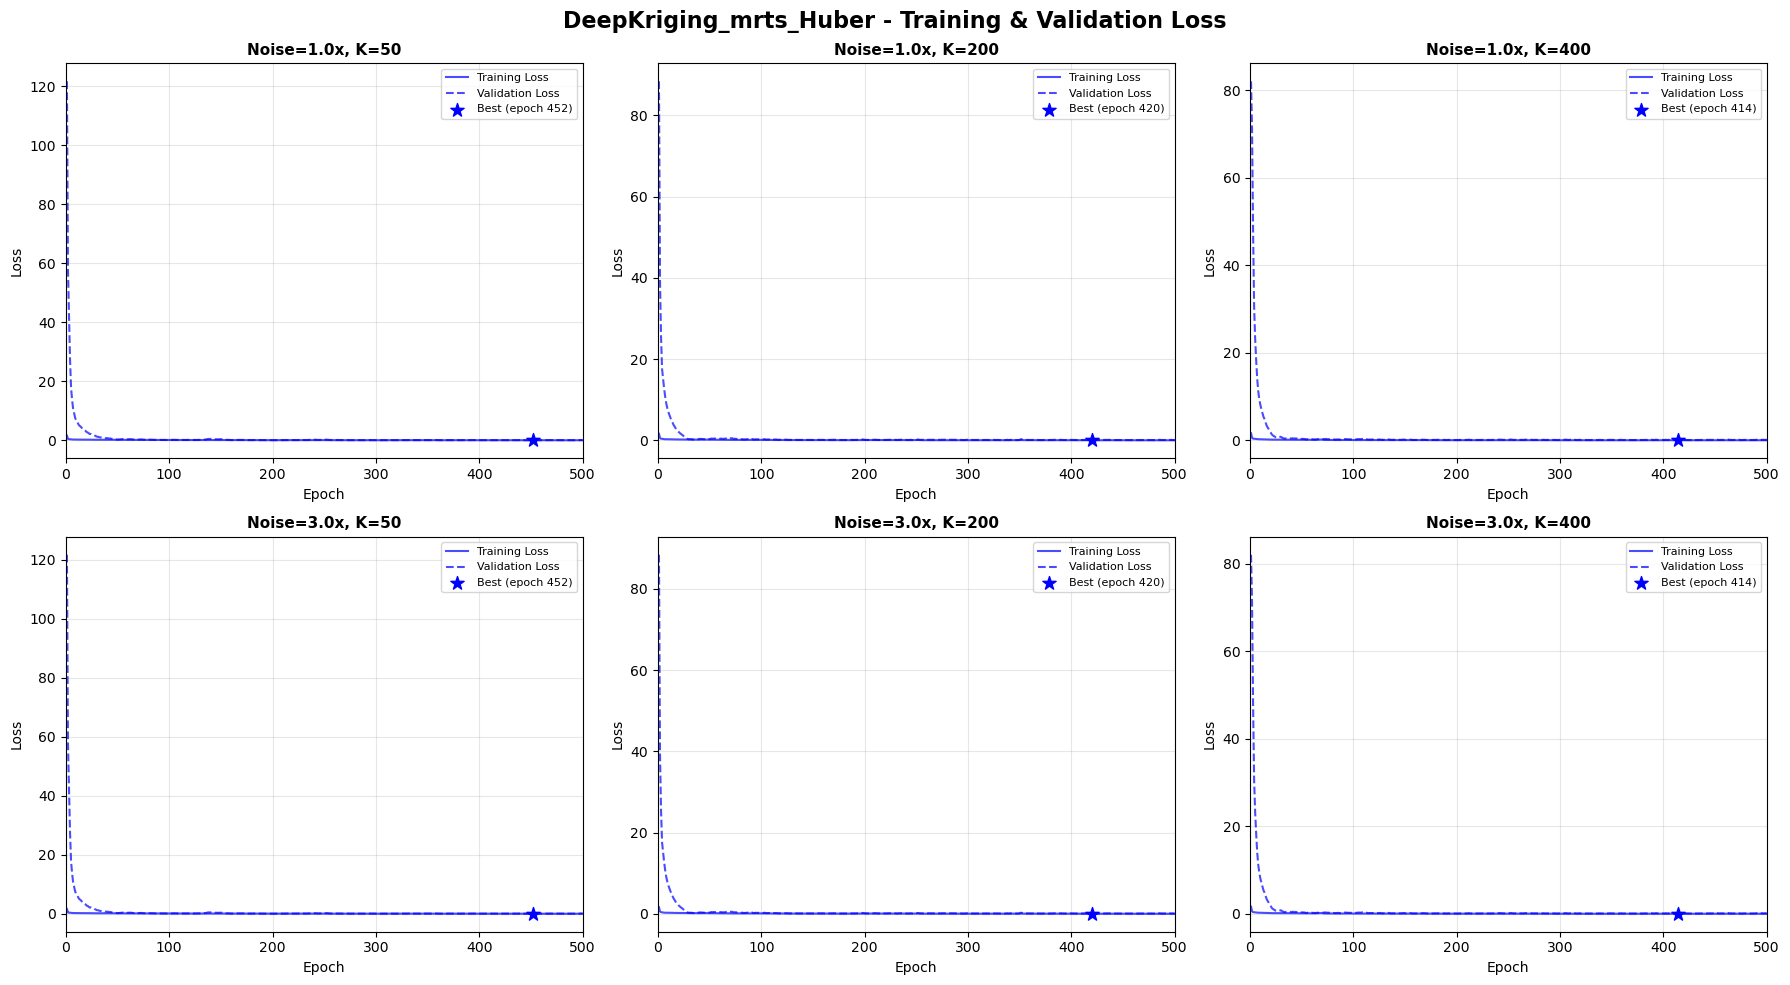

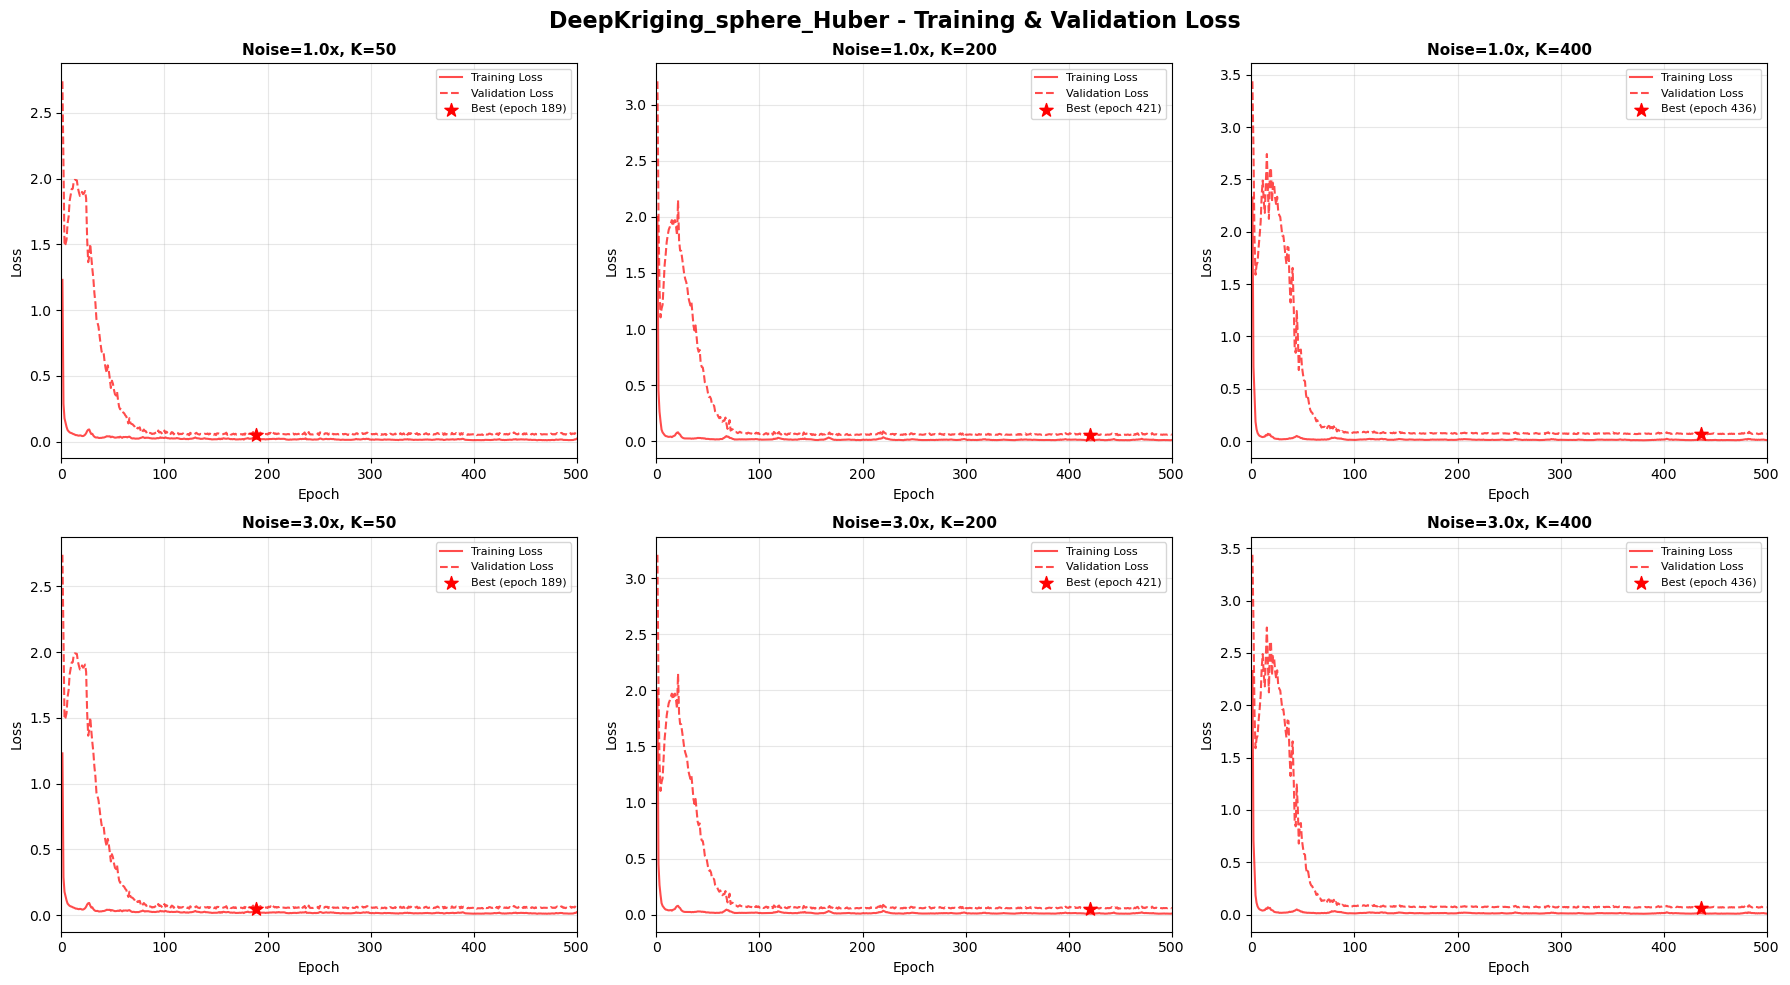

In [19]:
# DeepKriging_mrts_Huber
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DeepKriging_mrts_Huber - Training & Validation Loss', fontsize=16, fontweight='bold')

for idx, (noise_scale, num_basis) in enumerate([(1.0, 50), (1.0, 200), (1.0, 400), 
                                                  (3.0, 50), (3.0, 200), (3.0, 400)]):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    exp_key = f"signal_{signal_scale}_K_{num_basis}_mrts"
    
    if exp_key in training_histories:
        hist = training_histories[exp_key]['history']
        epochs_range = range(1, len(hist['loss']) + 1)
        
        # Training loss (solid line)
        ax.plot(epochs_range, hist['loss'], 'b-', linewidth=1.5, 
                label='Training Loss', alpha=0.7)
        
        # Validation loss (dashed line)
        ax.plot(epochs_range, hist['val_loss'], 'b--', linewidth=1.5, 
                label='Validation Loss', alpha=0.7)
        
        # Mark best epoch on validation loss
        best_epoch = np.argmin(hist['val_loss']) + 1
        ax.scatter([best_epoch], [hist['val_loss'][best_epoch-1]], 
                  color='blue', s=100, marker='*', zorder=5, 
                  label=f'Best (epoch {best_epoch})')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'Noise={noise_scale}x, K={num_basis}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, epochs)

plt.tight_layout()
plt.show()


# DeepKriging_sphere_Huber
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DeepKriging_sphere_Huber - Training & Validation Loss', fontsize=16, fontweight='bold')

for idx, (noise_scale, num_basis) in enumerate([(1.0, 50), (1.0, 200), (1.0, 400), 
                                                  (3.0, 50), (3.0, 200), (3.0, 400)]):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    exp_key = f"signal_{signal_scale}_K_{num_basis}_sphere"
    
    if exp_key in training_histories:
        hist = training_histories[exp_key]['history']
        epochs_range = range(1, len(hist['loss']) + 1)
        
        # Training loss (solid line)
        ax.plot(epochs_range, hist['loss'], 'r-', linewidth=1.5, 
                label='Training Loss', alpha=0.7)
        
        # Validation loss (dashed line)
        ax.plot(epochs_range, hist['val_loss'], 'r--', linewidth=1.5, 
                label='Validation Loss', alpha=0.7)
        
        # Mark best epoch on validation loss
        best_epoch = np.argmin(hist['val_loss']) + 1
        ax.scatter([best_epoch], [hist['val_loss'][best_epoch-1]], 
                  color='red', s=100, marker='*', zorder=5, 
                  label=f'Best (epoch {best_epoch})')
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'Noise={noise_scale}x, K={num_basis}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, epochs)

plt.tight_layout()
plt.show()

#### Visualization 2: Prediction Plots

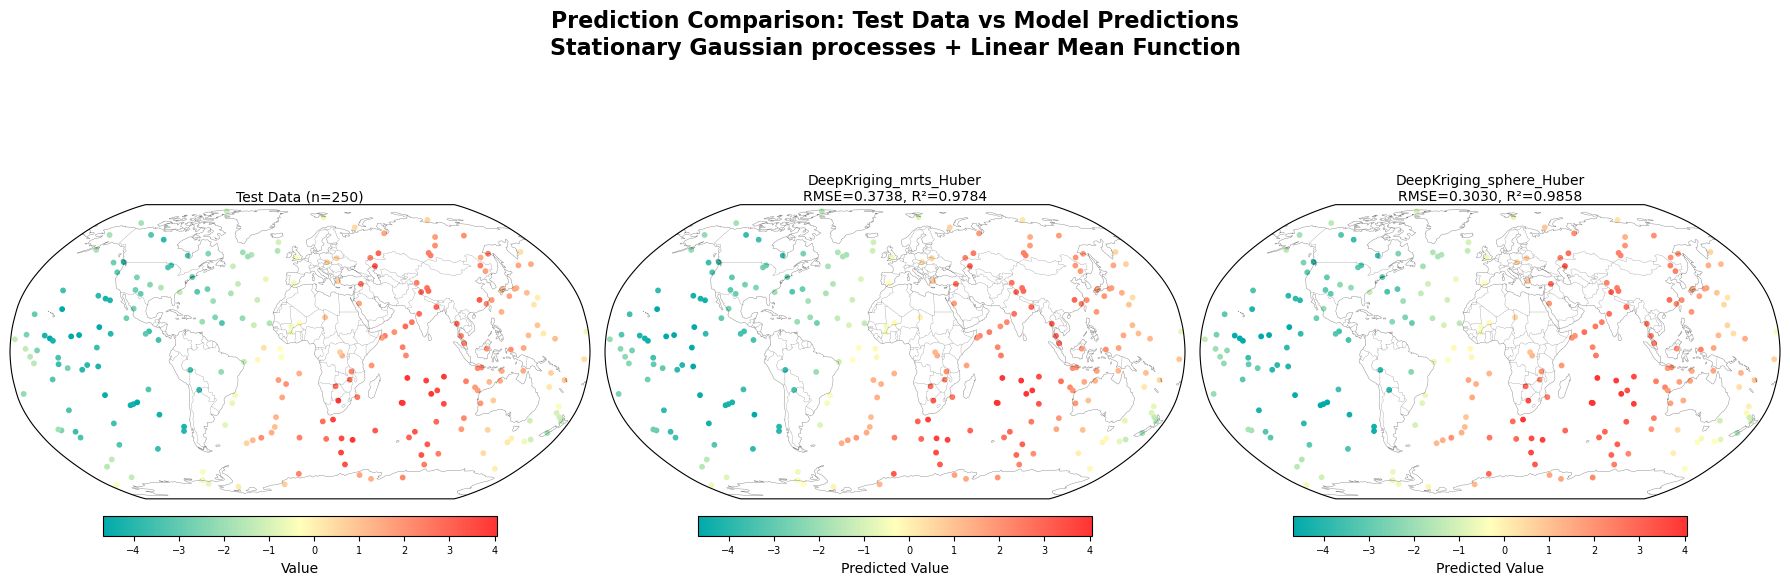

In [14]:
test_idx = predictions_data['mrts']['test_idx']
df = predictions_data['mrts']['dataframe']
test_locations = df.iloc[test_idx]
y_test = predictions_data['mrts']['y_true']

# Calculate global min/max for consistent color scale
all_values = [y_test]
for model_key in ['mrts', 'sphere']:
    all_values.append(predictions_data[model_key]['y_pred'])

all_values_concat = np.concatenate(all_values)
vmin = np.percentile(all_values_concat, 2)
vmax = np.percentile(all_values_concat, 98)


# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Test Data
create_subplot_robinson(
    fig, (1, 3, 1), test_locations, y_test, vmin, vmax,
    f'Test Data (n={len(test_idx)})',
    plot_type='prediction',
    cbar_label='Value'
)

# Subplot 2: DeepKriging_mrts_Huber predictions
y_pred_mrts = predictions_data['mrts']['y_pred']
rmse_mrts = np.sqrt(mean_squared_error(y_test, y_pred_mrts))
r2_mrts = r2_score(y_test, y_pred_mrts)

create_subplot_robinson(
    fig, (1, 3, 2), test_locations, y_pred_mrts, vmin, vmax,
    f'DeepKriging_mrts_Huber\nRMSE={rmse_mrts:.4f}, R²={r2_mrts:.4f}',
    plot_type='prediction',
    cbar_label='Predicted Value'
)

# Subplot 3: DeepKriging_sphere_Huber predictions
y_pred_sphere = predictions_data['sphere']['y_pred']
rmse_sphere = np.sqrt(mean_squared_error(y_test, y_pred_sphere))
r2_sphere = r2_score(y_test, y_pred_sphere)

create_subplot_robinson(
    fig, (1, 3, 3), test_locations, y_pred_sphere, vmin, vmax,
    f'DeepKriging_sphere_Huber\nRMSE={rmse_sphere:.4f}, R²={r2_sphere:.4f}',
    plot_type='prediction',
    cbar_label='Predicted Value'
)

plt.suptitle(
    'Prediction Comparison: Test Data vs Model Predictions\n'
    'Stationary Gaussian processes + Linear Mean Function',
    fontsize=16, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

#### Visualization 3: Residual Plots

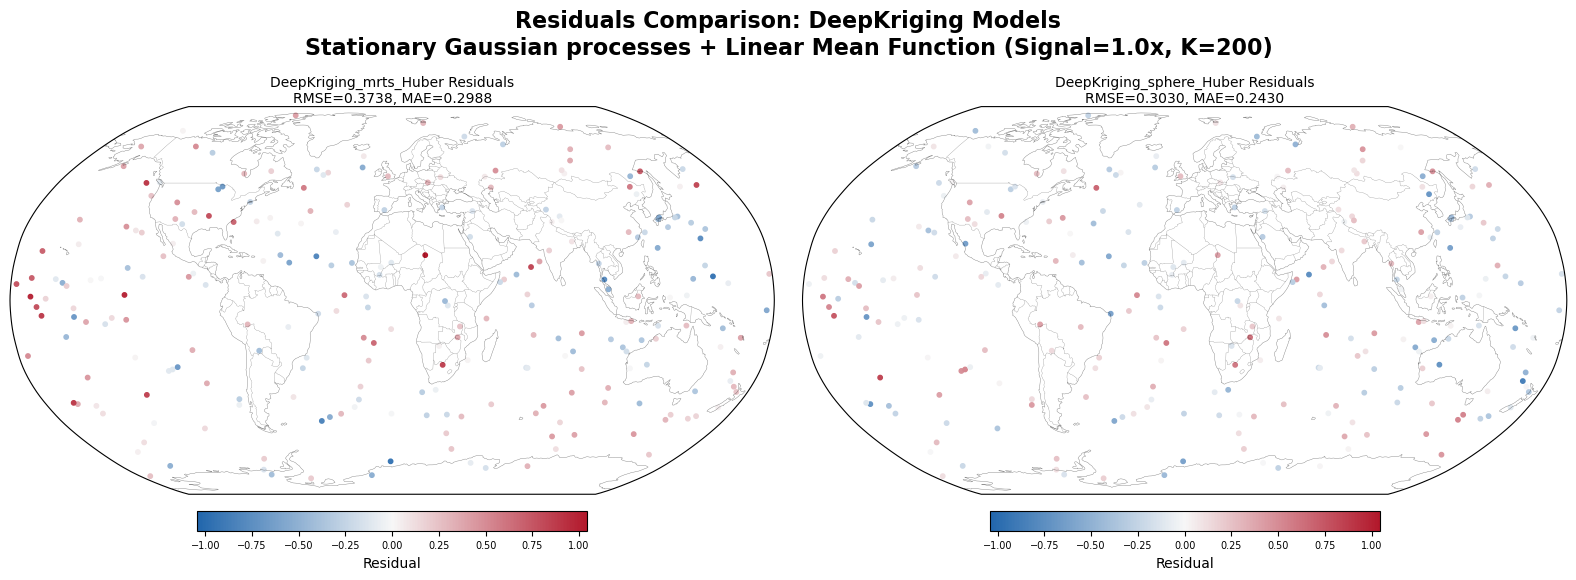

In [20]:
# Get test data
test_idx = predictions_data['mrts']['test_idx']
df = predictions_data['mrts']['dataframe']
test_locations = df.iloc[test_idx]
y_test = predictions_data['mrts']['y_true']

# Calculate residuals
residuals_mrts = y_test - predictions_data['mrts']['y_pred']
residuals_sphere = y_test - predictions_data['sphere']['y_pred']

# Calculate global max absolute value for symmetric color scale
vmax_abs = max(np.max(np.abs(residuals_mrts)), np.max(np.abs(residuals_sphere)))

# Create figure with 2 subplots
fig = plt.figure(figsize=(16, 6))

# Subplot 1: DeepKriging_mrts_Huber residuals
rmse_mrts = np.sqrt(mean_squared_error(y_test, predictions_data['mrts']['y_pred']))
mae_mrts = mean_absolute_error(y_test, predictions_data['mrts']['y_pred'])

create_subplot_robinson(
    fig, (1, 2, 1), test_locations, residuals_mrts, -vmax_abs, vmax_abs,
    f'DeepKriging_mrts_Huber Residuals\nRMSE={rmse_mrts:.4f}, MAE={mae_mrts:.4f}',
    plot_type='residual',
    cbar_label='Residual'
)

# Subplot 2: DeepKriging_sphere_Huber residuals
rmse_sphere = np.sqrt(mean_squared_error(y_test, predictions_data['sphere']['y_pred']))
mae_sphere = mean_absolute_error(y_test, predictions_data['sphere']['y_pred'])

create_subplot_robinson(
    fig, (1, 2, 2), test_locations, residuals_sphere, -vmax_abs, vmax_abs,
    f'DeepKriging_sphere_Huber Residuals\nRMSE={rmse_sphere:.4f}, MAE={mae_sphere:.4f}',
    plot_type='residual',
    cbar_label='Residual'
)

plt.suptitle(
    'Residuals Comparison: DeepKriging Models\n'
    'Stationary Gaussian processes + Linear Mean Function (Signal=1.0x, K=200)',
    fontsize=16, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()